# Overview

In this notebook we analyze the full historical series of the S&P 500 and tackle two distinct machine-learning problems:

1. **Forecasting next-day log-returns** using a neural network trained on past prices.  
2. **Applying the Triple Barrier Method**, introduced by López de Prado, to frame a classification task where the model must predict whether, within a future horizon, the price first hits the upper barrier, the lower barrier, or neither.

To evaluate temporal generalization, we adopt a *rolling evaluation scheme*:  
the model is trained once on the first 70% of the data and then tested on **10 consecutive, non-overlapping test windows** that move forward in time.  

This methodology allows us to assess whether the neural network genuinely learns meaningful patterns in the data, or merely exploits the long-term upward trend of the index.

The triple-barrier classification task is particularly useful in this regard, as it forces the model to distinguish local price dynamics rather than simply reproducing the global drift.


In [1]:
# Download data for the S&P 500 index from Yahoo Finance and save it to a CSV file.
#import yfinance as yf
#sp500_data = yf.download('^GSPC', start='1900-01-01')
#sp500_data.to_csv("sp500_data_long.csv")

In [2]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from fracdiff.sklearn import Fracdiff
from statsmodels.tsa.stattools import adfuller
from torch.utils.data import TensorDataset, DataLoader
from mypackage_utils import *
# For reproducibility
np.random.seed(42)
random.seed(42) 

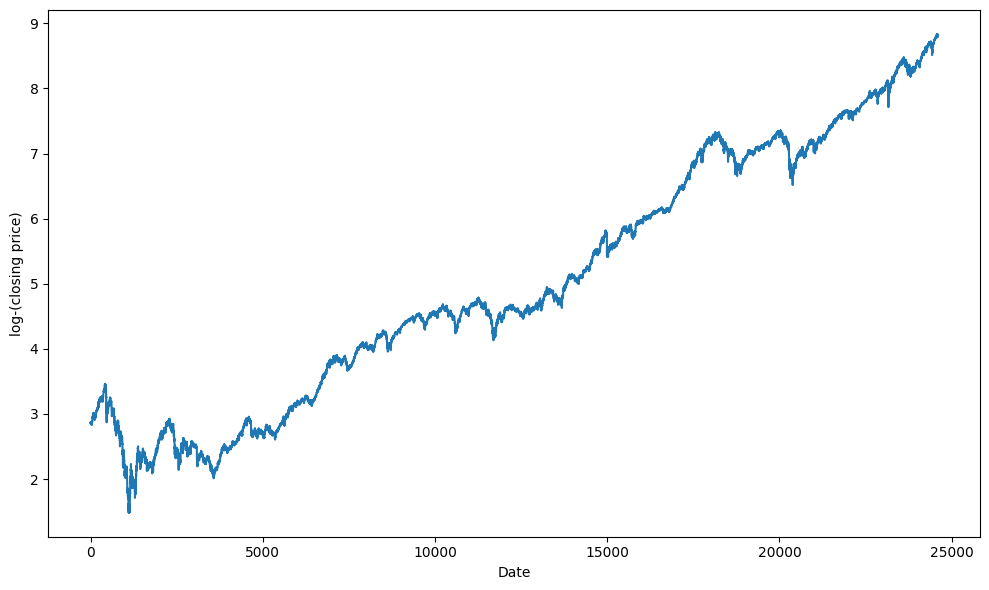

ADF test statistic: 0.840196239414464, p-value: 0.9922580695843458


In [3]:
sp500 = np.log(np.maximum(reading_file("sp500_data_long.csv").astype(float), 1e-8)) 
# We focus on the 'Close' prices
sp500 = sp500['Close'].to_numpy()
# Plot data
plt.figure(figsize=(10, 6))
plt.plot(sp500)
plt.xlabel("Date")
plt.ylabel("log-(closing price)")
plt.tight_layout()
plt.show()
# To check for stationarity, we perform the Augmented Dickey-Fuller test ( as by De Prado methodology )
adf_results = adfuller(sp500)
print(f"ADF test statistic: {adf_results[0]}, p-value: {adf_results[1]}")


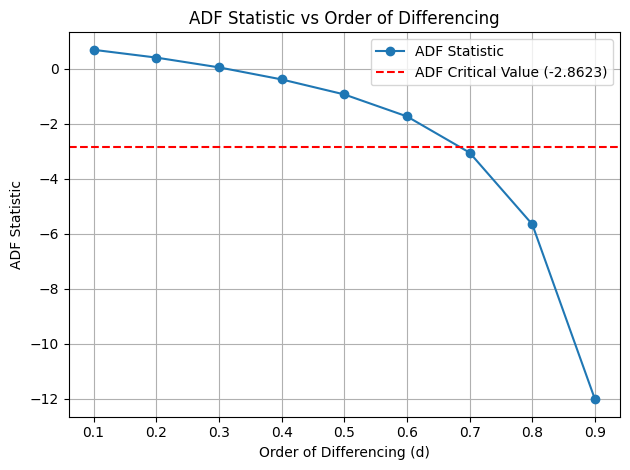

Estimated order of stationarity : ~ 0.685


In [4]:
# Find the best order of differentiation to make the series stationary. 

# Plot the ADF results vs order of differentiation
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

cval = -2.8623  # ADF critical value at 5% for n > 1000
window_size = 100
rows = []
for d in d_grid:
	frac = Fracdiff(d, window=window_size, window_policy="fixed") 	# the window size is now default=10   
	X = sp500.reshape(-1, 1)     
	X_fd = frac.fit_transform(X).ravel()
	# Set first (window_size - 1) values to NaN due to fixed window policy
	X_fd[:(window_size - 1)] = np.nan  
	# Remove NaN values for ADF test     								
	adf_results = adfuller(X_fd[~np.isnan(X_fd)])  
	rows.append({
		"d": d, "series": X_fd,
		"adf_stat": adf_results[0], "adf_p": adf_results[1],
	})
d_values = [r['d'] for r in rows]
adf_stats = [r['adf_stat'] for r in rows]
plt.title(f"ADF Statistic vs Order of Differencing")
plt.plot(d_values, adf_stats, marker='o', label='ADF Statistic')
plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
plt.xlabel("Order of Differencing (d)")
plt.ylabel("ADF Statistic")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
# Intersection between ADF stats and critical value: find first crossing where ADF goes from > cval to <= cval
d_values  = np.asarray(d_values, dtype=float)
adf_stats = np.asarray(adf_stats, dtype=float)
mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
idx = np.where(mask)[0]
i = idx[0]
# Linear interpolation
d1, d2 = d_values[i], d_values[i+1]
a1, a2 = adf_stats[i], adf_stats[i+1]
d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
print(f"Estimated order of stationarity : ~ {d_star:.3f}")

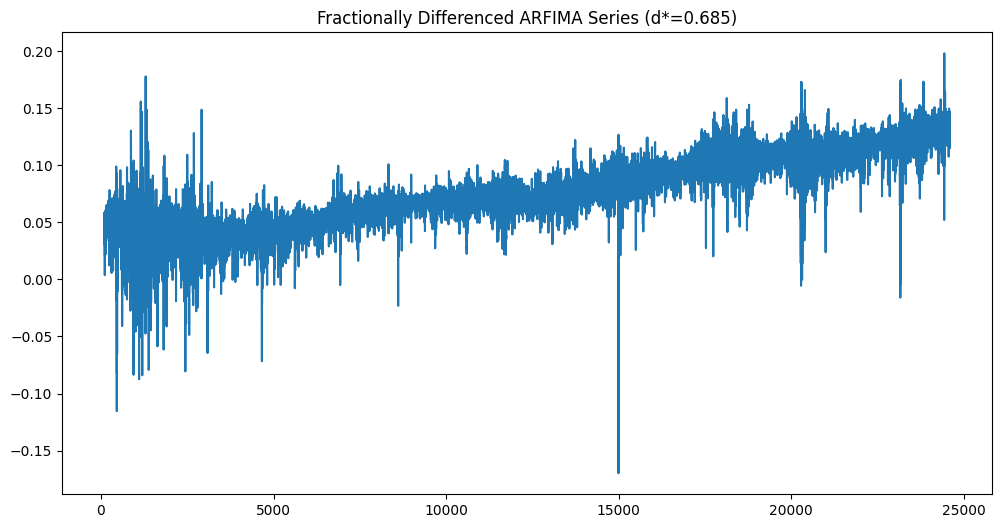

In [5]:
# Determine the fractionally differenced series using the estimated d_star
fd_sp500 = Fracdiff(d=d_star, window=window_size, window_policy="fixed")
dataset = fd_sp500.fit_transform(sp500.reshape(-1, 1)).ravel()
dataset[:(window_size - 1)] = np.nan
plt.figure(figsize=(12, 6))
plt.title(f"Fractionally Differenced ARFIMA Series (d*={d_star:.3f})")
plt.plot(dataset)
plt.show()

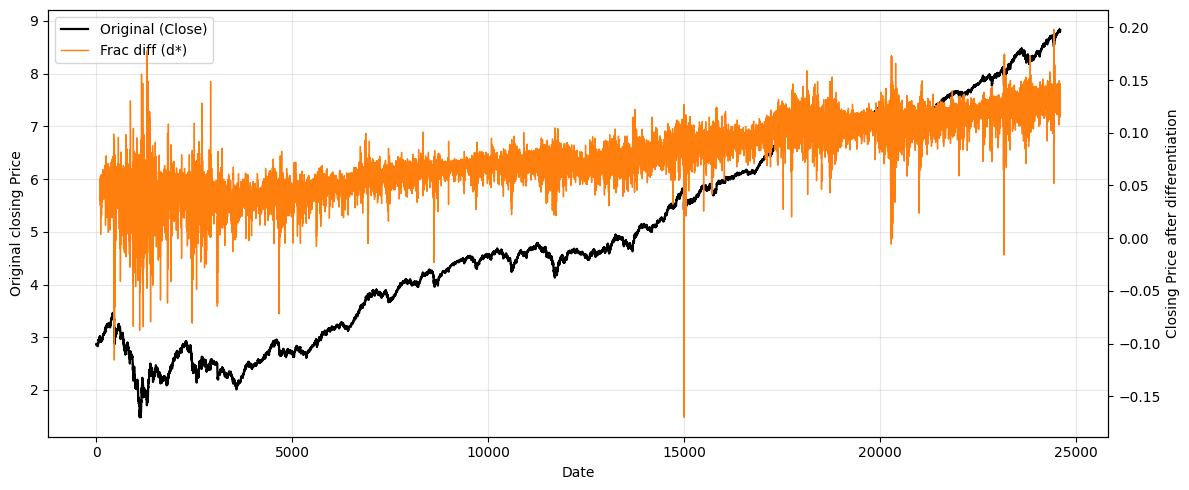

In [6]:
#Plot the original, integer-differenced, and fractionally differenced series on the same figure using twin y-axes.

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: original prices 
ax1.plot( sp500, lw=1.6, color="black", label="Original (Close)")
ax1.set_ylabel("Original closing Price")
ax1.set_xlabel("Date")

# Right axis: integer and fractional differences 
ax2 = ax1.twinx()
ax2.plot( dataset, lw=1.0, color="tab:orange", label="Frac diff (d*)")
ax2.set_ylabel("Closing Price after differentiation")

# Legend 
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Regression problem using NN

In [7]:
# Prepare dataset for ML algorithms
# Log returns as target variable
target = np.diff(sp500)
mask = np.isfinite(dataset[:-1]) & np.isfinite(target)
X = dataset[:-1][mask].reshape(-1, 1)
y = target[mask].reshape(-1, 1)

# Split the data into training and testing sets
train_size = int(len(X) * 0.70)
test_size = int(len(X) * 0.03)
train_data = X[:train_size]
target_train = y[:train_size]

# Normalize data
scaler_data = StandardScaler()
train_data = scaler_data.fit_transform(train_data)
test_data = []
target_test = []
for i in range(10):
	test_data.append(scaler_data.transform(X[train_size + i * test_size:train_size + (i + 1) * test_size]))
	target_test.append(y[train_size + i * test_size:train_size + (i + 1) * test_size])

100%|██████████| 500/500 [00:19<00:00, 25.40it/s, lr=0.001, train=0.00014] 


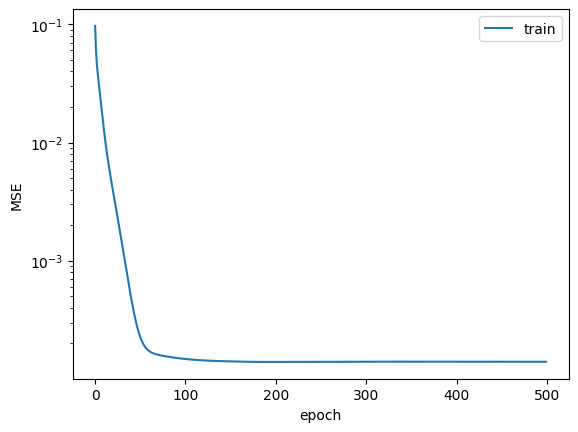

In [8]:
# Define the MLP model
batch_size = 512
nhidden = 4
model = nn.Sequential(nn.Linear(1, nhidden),
						nn.ReLU(),
						nn.Linear(nhidden, 1))

# Transforming data into tensor
train_data = torch.as_tensor(train_data, dtype=torch.float32)
target_train = torch.as_tensor(target_train, dtype=torch.float32).view(-1, 1)
for i in range (10):
	test_data[i] = torch.as_tensor(test_data[i], dtype=torch.float32)
	target_test[i] = torch.as_tensor(target_test[i], dtype=torch.float32).view(-1, 1)

# Dataset e DataLoader
train_dataset = TensorDataset(train_data, target_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Shuffle False because of time series data

# Defining loss, optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training loop
n_epochs = 500
train_curve= []
training_loop = tqdm(range(n_epochs)) 

for epoch in training_loop:
	# Training mode
	model.train() 
	running = 0.0 
	for batch_data, batch_targets in train_loader:
		# Reset computation graph
		optimizer.zero_grad()
		# Forward pass
		outputs = model(batch_data)
		# Compute training loss on batch
		loss = criterion(outputs, batch_targets)
		# Compute gradient 
		loss.backward()
		# Gradient step
		optimizer.step()
		# Loss per batch 
		running += loss.item()
	# Loss per epoch
	train_epoch = running/len(train_loader)

	# Store train and validation loss
	train_curve.append(train_epoch)

	# Print loss in the progression bar
	training_loop.set_postfix(train=train_epoch,  lr=optimizer.param_groups[0]['lr'])

# Plot losses
plt.figure()
plt.plot(train_curve, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()			


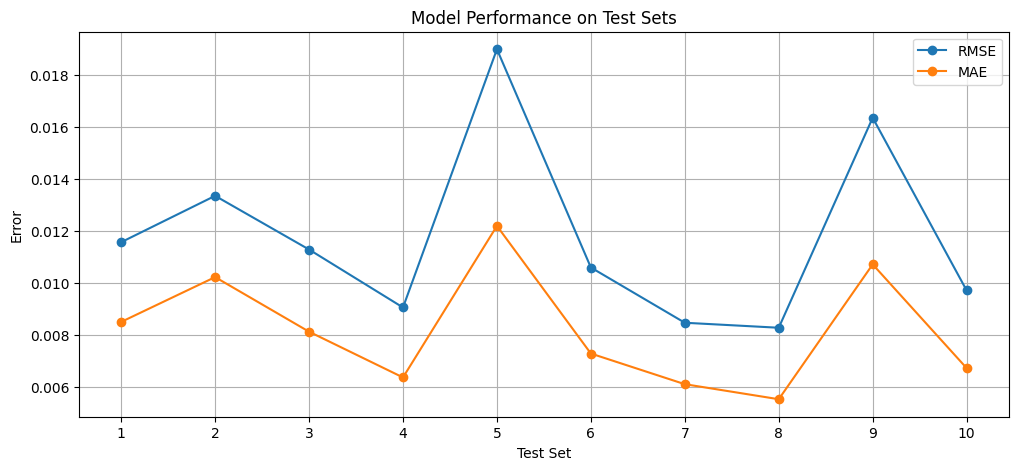

Train RMSE: 0.011874, MAE: 0.007411
Test Set 1: sample standard deviation of Predictions: 0.000334
Test Set 2: sample standard deviation of Predictions: 0.000403
Test Set 3: sample standard deviation of Predictions: 0.000340
Test Set 4: sample standard deviation of Predictions: 0.000261
Test Set 5: sample standard deviation of Predictions: 0.000476
Test Set 6: sample standard deviation of Predictions: 0.000310
Test Set 7: sample standard deviation of Predictions: 0.000252
Test Set 8: sample standard deviation of Predictions: 0.000249
Test Set 9: sample standard deviation of Predictions: 0.000430
Test Set 10: sample standard deviation of Predictions: 0.000297


In [9]:

# Metrics evaluation 
rmse_list_nn = []
mae_list_nn = []
loss_list_nn = []
std_nn = []
train_evaluation = []
model.eval()
with torch.no_grad():
	# Train evaluation
	predcitions_train = model(train_data).numpy()
	train_evaluation.append( np.sqrt(mean_squared_error(target_train.numpy(), predcitions_train)))
	train_evaluation.append(mean_absolute_error(target_train.numpy(), predcitions_train))
	# Test evaluation on 10 test sets
	for i in range(10):
		predictions = model(test_data[i]).numpy()
		std_nn.append(np.std(predictions))
		loss_list_nn.append(mean_squared_error(target_test[i].numpy(), predictions))
		rmse_list_nn.append(np.sqrt(loss_list_nn[-1]))
		mae_list_nn.append(mean_absolute_error(target_test[i].numpy(), predictions))
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()
print(f"Train RMSE: {train_evaluation[0]:.6f}, MAE: {train_evaluation[1]:.6f}")
# Print sample standard deviation of predictions on each test set
for i in range(10):
	print(f"Test Set {i+1}: sample standard deviation of Predictions: {std_nn[i]:.6f}")


# Regression problem using LR

In [10]:
model_lr = LinearRegression()
model_lr.fit(train_data, target_train)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr = []
mae_list_lr = []
std_lr = []
# Evaluate model on training set
pred_train_lr = model_lr.predict(train_data)
train_evaluation_lr = []
train_evaluation_lr.append( np.sqrt(mean_squared_error(target_train.numpy(), pred_train_lr)))
train_evaluation_lr.append(mean_absolute_error(target_train.numpy(), pred_train_lr))
# Evaluate model on test sets 
for i in range(10):
	pred = model_lr.predict(test_data[i])
	std_lr.append(np.std(pred))
	rmse_list_lr.append(np.sqrt(mean_squared_error(target_test[i].numpy(), pred)))
	mae_list_lr.append(mean_absolute_error(target_test[i].numpy(), pred))

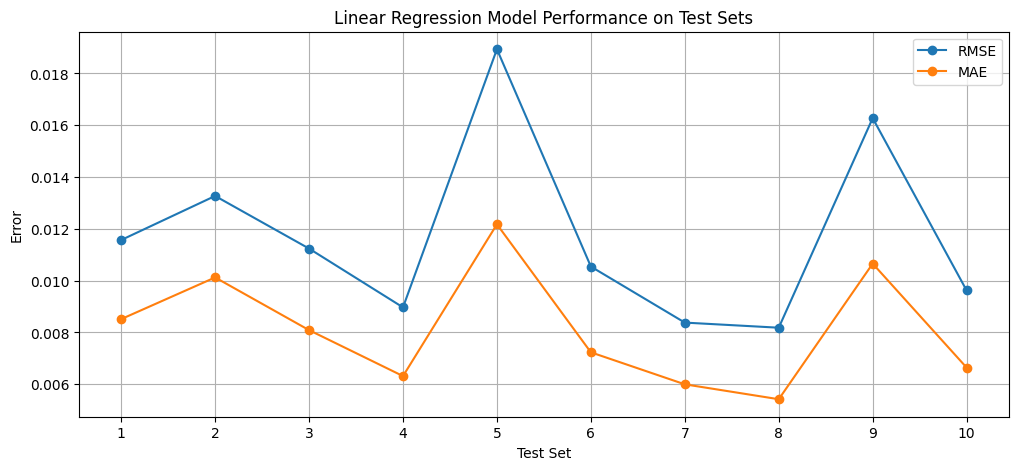

Train RMSE: 0.011886, MAE: 0.007411
Test Set 1: sample standard deviation of Predictions: 0.000102
Test Set 2: sample standard deviation of Predictions: 0.000117
Test Set 3: sample standard deviation of Predictions: 0.000100
Test Set 4: sample standard deviation of Predictions: 0.000075
Test Set 5: sample standard deviation of Predictions: 0.000163
Test Set 6: sample standard deviation of Predictions: 0.000093
Test Set 7: sample standard deviation of Predictions: 0.000073
Test Set 8: sample standard deviation of Predictions: 0.000072
Test Set 9: sample standard deviation of Predictions: 0.000139
Test Set 10: sample standard deviation of Predictions: 0.000086


In [11]:
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()
print(f"Train RMSE: {train_evaluation_lr[0]:.6f}, MAE: {train_evaluation_lr[1]:.6f}")
# Print sample standard deviation of predictions on each test set
for i in range(10):
	print(f"Test Set {i+1}: sample standard deviation of Predictions: {std_lr[i]:.6f}")


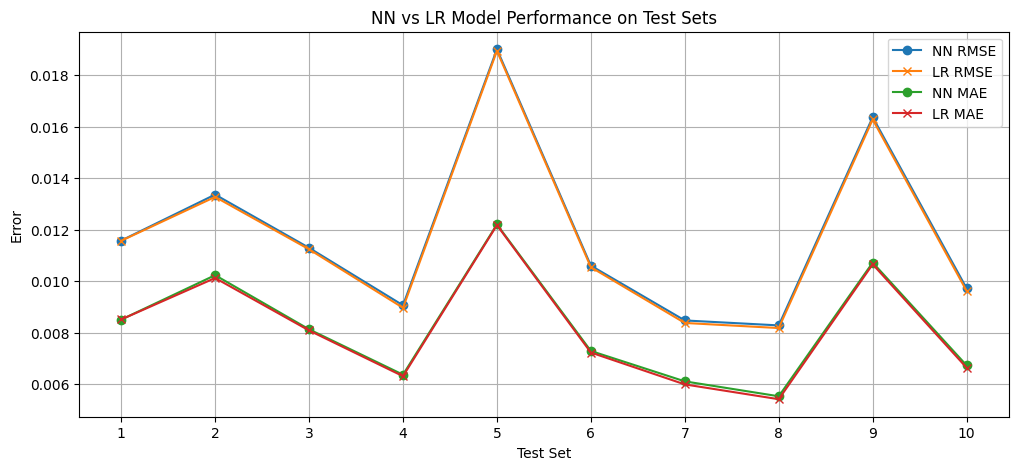

In [12]:
# Compare NN and LR models plotting the RMSE and MAE for each test set
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr, marker='x', label='LR MAE')
plt.title("NN vs LR Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()


# Triple Barrier Method

Starting from a reference time $t_i$ , we construct a "rectangle" in price–time space bounded by **two horizontal barriers**—a profit-taking level and a stop-loss level—and **one vertical barrier**, located at $t_i + h$.

The target variable is determined by the *first* barrier that the price path touches:

* we assign **+1** if the price reaches the **upper** barrier before the vertical barrier,
* we assign **-1** if it hits the **lower** barrier first,
* we assign **0** if neither horizontal barrier is touched before $t_i + h$.

A crucial preliminary step, emphasized by López de Prado, is that the width of the horizontal barriers cannot be set using fixed thresholds. Instead, they must scale with the **realized volatility** of the asset. Incorporating volatility ensures that the barrier placement reflects the current level of risk in the market: when volatility is high, the barriers widen; when volatility is low, they become tighter. This dynamic sizing produces labels that are far more robust and economically meaningful.


In [13]:
def get_daily_vol(close, span):
    # Convert to pandas Series to perform .diff() and .ewm()
    close_series = pd.Series(close)
    # Log-returns
    returns = close_series.diff()
    # EWMA volatility (pandas)
    vol = returns.ewm(span=span, adjust=False).std()
    # return as NumPy array
    return vol.to_numpy()
    
# Threshold horizonal barrier and vertical one
def get_events(close, volatility, span_vol, h=10, vol_mult=1.0):
    N = len(close)
    # To avoid initial NaN in volatility
    valid = np.arange(span_vol, N  - h) 
    # Vertical barrier indices
    terminal = valid + h 
    # Horizontal barrier threshold          
    threshold = volatility[valid] * vol_mult
    
    return valid, terminal, threshold

def apply_triple_barrier(close, valid, terminal, threshold, multiplier):
    pt_mult, sl_mult = multiplier
    N = len(valid)
    pt_touch = np.full(N, -1, dtype=int)
    sl_touch = np.full(N, -1, dtype=int)

    for k in range(N):
        start = valid[k]
        end = terminal[k]
        # Price path from event start to end
        p0 = close[start]
        path = close[start:end+1]
        # Return on the path
        price_return = np.log(path) - np.log(p0)

        # Profit-take barrier ( Upper barrier)
        pt_level = pt_mult * threshold[k]
        hits = np.where(price_return >= pt_level)[0]
        if hits.size > 0:
            pt_touch[k] = start + hits[0]
        # Stop-Loss barrier ( Lower barrier)
        sl_level = -sl_mult * threshold[k]
        hits = np.where(price_return <= sl_level)[0]
        if hits.size > 0:
            sl_touch[k] = start + hits[0]

    return pt_touch, sl_touch

def labeling(close, valid, terminal, pt_touch, sl_touch):

    N = len(valid)
    labels = np.zeros(N)

    for k in range(N):
        i = valid[k]
        v = terminal[k]
        pt = pt_touch[k]
        sl = sl_touch[k]
        # Both initialized to -1 (no touch)
        if pt != -1 and sl != -1:
            # Both triggered → pick the earliest
            labels[k] = +1 if pt < sl else -1
        
        elif pt != -1:
            labels[k] = +1
        
        elif sl != -1:
            labels[k] = -1
			
        else:
            # No barrier touched, give label based on price movement
            price_return = np.log(close[v]) - np.log(close[i])
            labels[k] = np.sign(price_return)
            #labels[k] = 0

    return labels


In [14]:
span_vol = 100

# Estimate daily volatility
daily_vol = get_daily_vol(sp500, span=span_vol)

# Determining thresholds and vertical barrier
valid_index, terminal, threshold = get_events( sp500, daily_vol, span_vol, h=10, vol_mult=1.0)

# Labeling with triple-barrier method
pt_touch, sl_touch = apply_triple_barrier( sp500, valid_index, terminal, threshold, multiplier=[1, 1] )#
labels = labeling(sp500, valid_index, terminal, pt_touch, sl_touch)

In [15]:
# Prepare data
X_class = sp500[valid_index].reshape(-1, 1)
# Shift labels to be in {0, 1, 2} because of CrossEntropyLoss
y_class = labels + 1          
y_class = y_class.astype(int)

# Train size
train_size = int(len(X_class) * 0.70)
# Test size for each window
test_size = int(len(X_class) * 0.03)

X_train = X_class[:train_size]
y_train = y_class[:train_size]
# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_windows = []
y_test_windows = []
for i in range(10):
    X_test_i = X_class[train_size + i * test_size:train_size + (i + 1) * test_size]
    y_test_i = y_class[train_size + i * test_size:train_size + (i + 1) * test_size]
    X_test_i_scaled = scaler.transform(X_test_i)
    X_test_windows.append(X_test_i_scaled)
    y_test_windows.append(y_test_i)

# Transform to tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensors = []
y_test_tensors = []
for i in range(10):
	X_test_tensors.append(torch.tensor(X_test_windows[i], dtype=torch.float32))
	y_test_tensors.append(torch.tensor(y_test_windows[i], dtype=torch.long))



100%|██████████| 300/300 [00:16<00:00, 18.58it/s, lr=0.001, train=0.702]


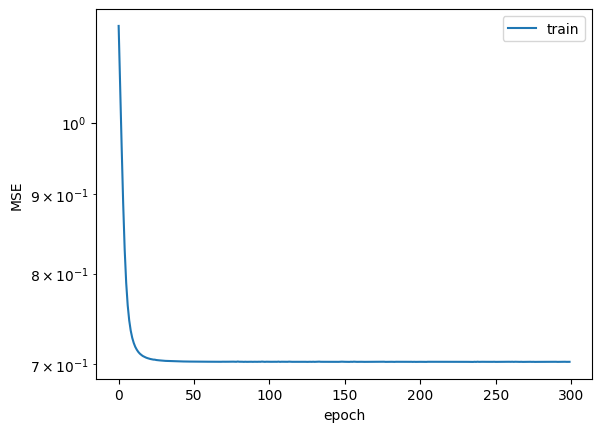

In [16]:
batch_size = 256
# Create dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

nhidden = 4
# Define model, criterion and optimizer
model_tbr = nn.Sequential(	nn.Linear(1, nhidden),
        					nn.ReLU(),
        					nn.Linear(nhidden, 3))
# Since the label are just two  ( not using label zero for no toch barrier) we should use 2 as output	

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tbr.parameters(), lr=1e-3)

epochs = 300
train_losses = []  

pbar = tqdm(range(epochs))
for epoch in pbar:
    model_tbr.train()
    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model_tbr(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        # Accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)


    # End epoch statistics
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    train_losses.append(train_loss)

    # Print loss in the progression bar
    pbar.set_postfix(train=train_loss,  lr=optimizer.param_groups[0]['lr'])

# Save the final model weights
#torch.save(model.state_dict(), weight_filename)
# Plot losses
plt.figure()
plt.plot(train_losses, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()	



In [17]:
# Evaluate model on training set
model_tbr.eval()
with torch.no_grad():
	outputs = model_tbr(X_train_tensor)      
	loss = criterion(outputs, y_train_tensor)
	preds = outputs.argmax(dim=1)                      
	train_acc = (preds == y_train_tensor).float().mean().item()

print("Training loss:", loss.item())
print("Training accuracy:", train_acc)

Training loss: 0.7022532820701599
Training accuracy: 0.5638930797576904


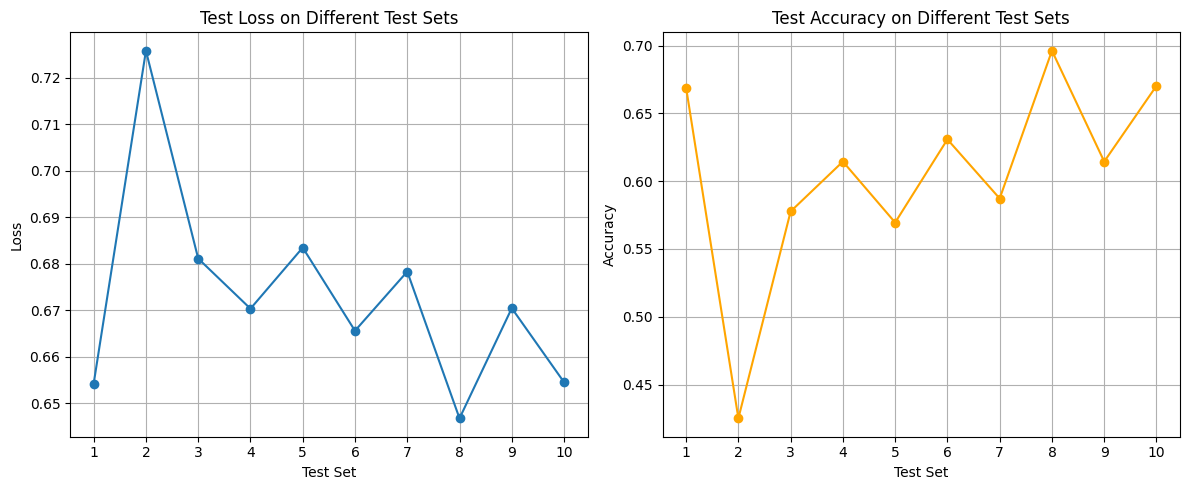

In [18]:
all_test_losses = []
all_test_accs = []
# Test evaluation on the 10 test sets
model_tbr.eval()
with torch.no_grad():
    for i in range(10): 
        outputs = model_tbr(X_test_tensors[i]) 
        loss = criterion(outputs, y_test_tensors[i]).item()
        preds = outputs.argmax(dim=1)
        acc = (preds == y_test_tensors[i]).float().mean().item()
        all_test_losses.append(loss)
        all_test_accs.append(acc)

# Plot test losses and accuracies
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), all_test_losses, marker='o', label='Test Loss')
plt.title("Test Loss on Different Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Loss")
plt.xticks(range(1, 11))
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), all_test_accs, marker='o', label='Test Accuracy', color='orange')
plt.title("Test Accuracy on Different Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.grid()
plt.tight_layout()
plt.show()